R (noise): 0.00019489071022227433
Q: 5.846721306668229e-05


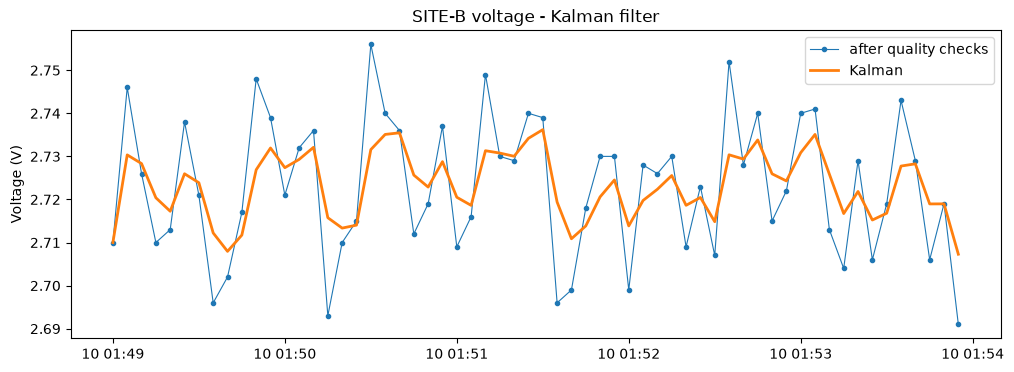

In [1]:
# test the Kalman filter on voltage
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
from data_quality import run_quality_checks
from kalman_filter import apply_kalman, estimate_noise

raw = pd.read_csv("../data/member1_raw_sensor_stream.csv")
clean = run_quality_checks(raw)

r = estimate_noise(clean, "voltage_v")
q = 0.3 * r
print("R (noise):", r)
print("Q:", q)

clean["voltage_kf"] = apply_kalman(clean, "voltage_v", q, r)

# plot one session
site = clean[clean["site_id"] == "SITE-B"]
one = site[site["session_id"] == site["session_id"].iloc[0]]

plt.figure(figsize=(12, 4))
plt.plot(one["timestamp_utc"], one["voltage_v"], "o-", markersize=3, linewidth=0.8, label="after quality checks")
plt.plot(one["timestamp_utc"], one["voltage_kf"], linewidth=2, label="Kalman")
plt.title("SITE-B voltage - Kalman filter")
plt.ylabel("Voltage (V)")
plt.legend()
plt.show()

In [2]:
# try different Q values and compare with the reference file
import numpy as np

ref = pd.read_csv("../data/member1_sensor_health.csv")
m = clean.merge(ref[["record_id", "voltage_v"]], on="record_id", suffixes=("", "_ref"))

def rmse(a, b):
    return np.sqrt(((a - b) ** 2).mean())

print("Raw RMSE:", round(rmse(m["voltage_v"], m["voltage_v_ref"]), 4))
print()

for ratio in [0.01, 0.1, 0.3, 1.0]:
    kf = apply_kalman(m, "voltage_v", ratio * r, r)
    jitter = kf.groupby(m["session_id"]).diff().std() / m.groupby("session_id")["voltage_v"].diff().std()
    print(f"Q = {ratio} x R  ->  RMSE: {rmse(kf, m['voltage_v_ref']):.4f}   jitter left: {jitter:.0%}")

Raw RMSE: 0.01

Q = 0.01 x R  ->  RMSE: 0.0097   jitter left: 11%
Q = 0.1 x R  ->  RMSE: 0.0089   jitter left: 22%
Q = 0.3 x R  ->  RMSE: 0.0084   jitter left: 34%
Q = 1.0 x R  ->  RMSE: 0.0082   jitter left: 53%
